# Successor representations

Up until now, we have seen that state abstraction methods don't seem to fit the data all that well. Indeed, none of the methods tried so far perform better than Ott's initial model. The method for which I had the highest hopes was the bisimulation metric [REFERENCE], which basically gives us a metric between state pairs based on the similarity in their rewards and transitional probabilities. When grouping states of increasing distances, the accuracy of the value and therefore the total return diminish, but in a controlled way. So in other words, this approach is merging states such that when computing the solution based on the abstracted MDP, the loss in return on the full MDP is bounded. While it does not strictly ensures the most efficient abstraction of the MDP (i.e. highest possible return for a given state space size), it tends to perform very well, i.e. the return of the abstract MDP optimal policy are usually quite high given the amount of reduction. 

The hope was that participants are doing something like it: generate an abstracted representation of the ground MDP that doesn't sacrifice too much in terms of return, and compute their solution based on that, which should be reflected in the participant's decision values. That didn't work out. And unfortunately, neither did any of the other methods I have tested (boltzman, model similarity, q abstraction...), which in hindsight makes sense cause they are all downstream from bisimulation metric in terms of coarseness [REFERENCE]. 

These results suggest that if participants do generate simplified representations of the task, they do so using different algorithmic principles than that used in state abstraction. This is in itself an interesting finding. Provided that the efforts in the computer science literature are motivated by control problems faced in robotics, the fact that the methods they have developped for solving the same problem doesn't apply to humans might explain why machines typically struggle where we excel or require much more computational resources than we do.

So what might be the computational principles participants rely on to generate simplified representation of the task that they are able to deal with in terms of complexity? Our attention now turns towards successor representation. Successor representation consists in representing the dynamics of the environment using an occupancy matrix under a given policy. The occupancy matrix contains the probability of visiting state s' in the future, given that one is in state s currently. Whereas the transition probability matrix contains the probability of visiting state s' at the next time step starting from state s and given action a, the occupancy matrix contains the (discounted) probability of visiting the other states at any point in the future. 

Successor representation has been investigated quite extensively in cognitive neuroscience, and there is some evidence suggesting that activation in place cells in the hippocampus and that grid cells in the entorhinal cortex might be encoding quantities related to successor representations, especially in the domain of spatial naviagation, but also in more abstract spaces. Successor representation is as a much more cognitive framework, compared to state abstraction per se which comes from computer science. 

Critically, successor representation also offers several ways to simplify task representation. First, the value function can be calculated much more efficiently based on the occupancy matrix by a simple multiplication operation with the reward function. Successor representation is therefore in itself a more 'efficient' solution to the planning problem, though it is yielding worst performance when the transitional probability of the environment change compare to full model based approaches. But in addition, the occupancy matrix can be decomposed in simpler components, and it could be that the participants are able to decompose complicated tasks in simpler ones that way. In addition, it makes it possible to identify bottleneck states, which might be interesting when it comes to partitioning the task into hierarchical chunks. And many more options exist.

In the next few chapters, we will further explore all these various approaches to see whether some yield good performance on our participants data. In the current chapter, we will focus on implementing and exploring the occupancy matrix of our task under the optimal and stochastic policy. 

# Generate successor representation under the optimal policy

100.00000000000013
0.99
0.9999999999999999 1.0000000000000002
0.0 1.0
is SR close to I: False
max |SR-I|: 99.00000000000013


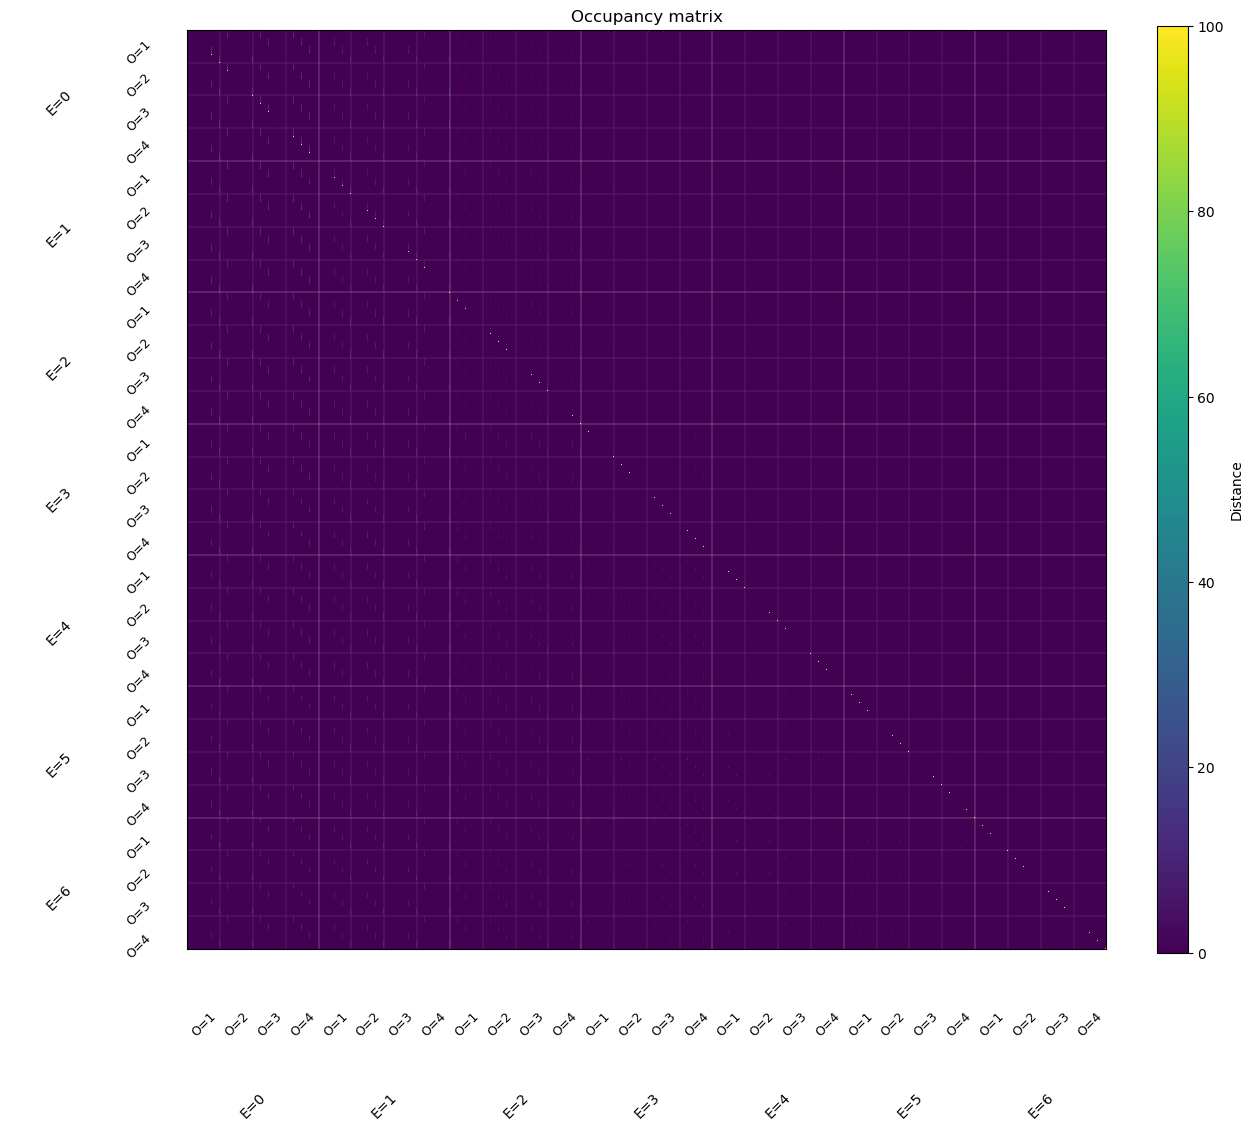

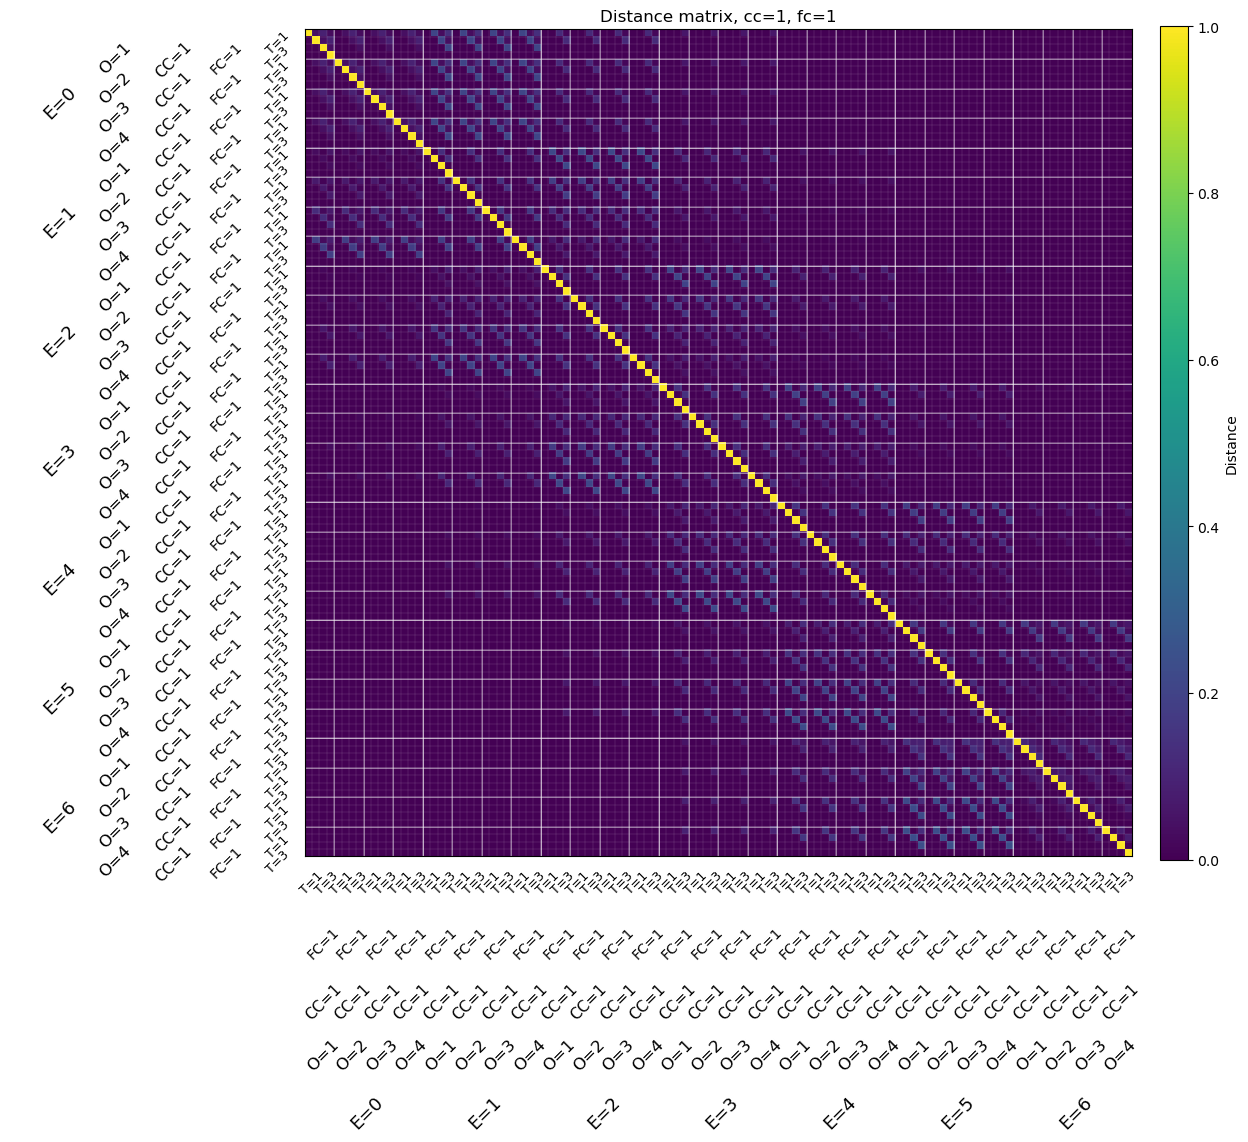

1.0


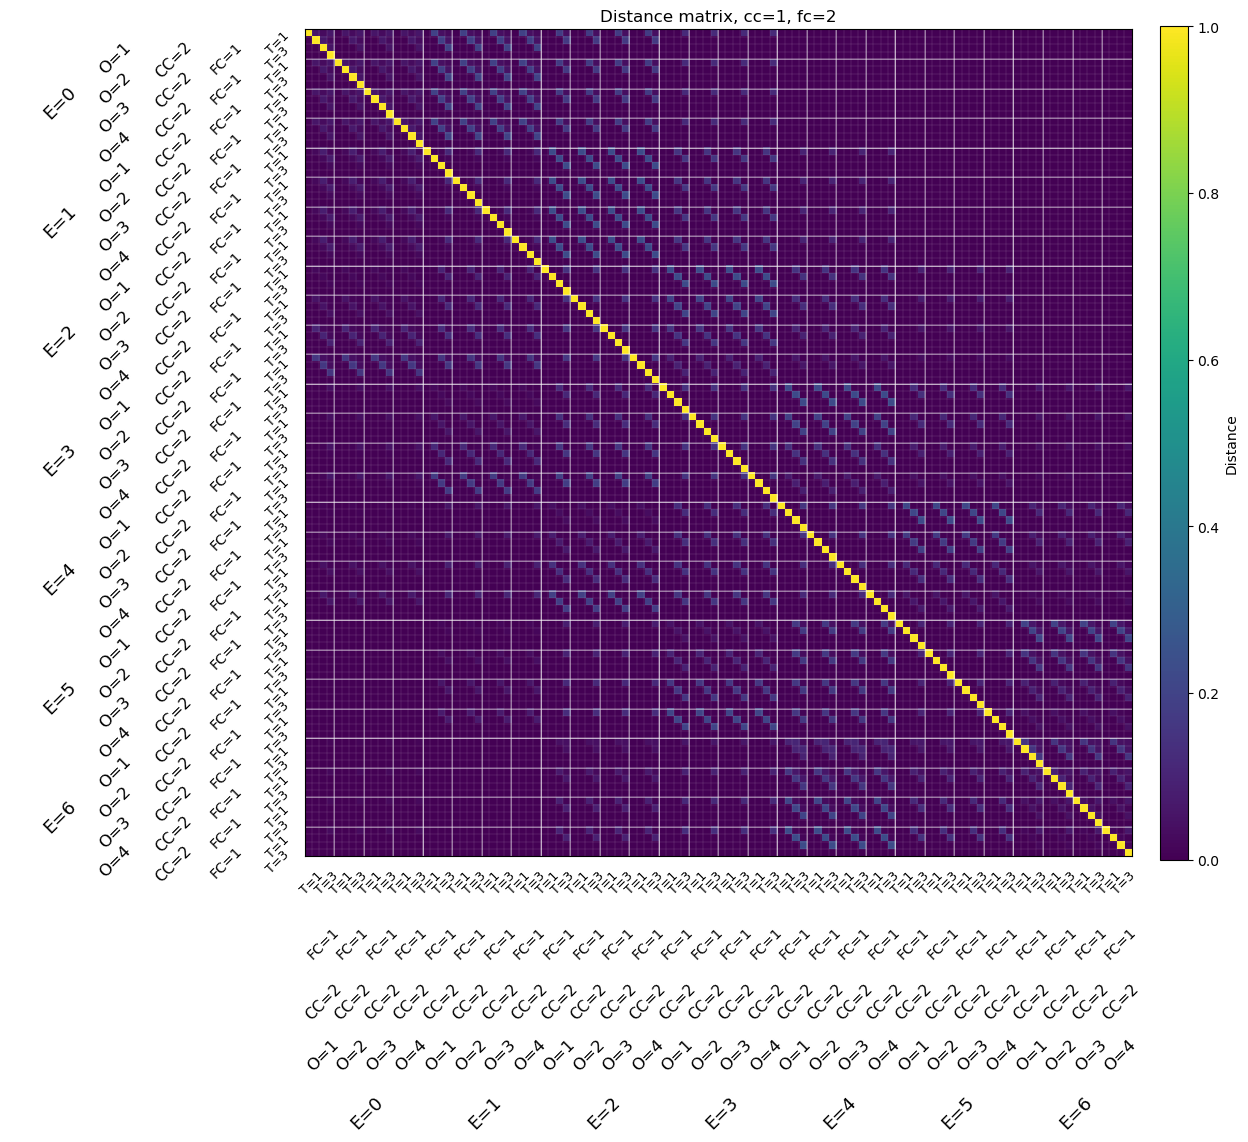

1.0000000000000002


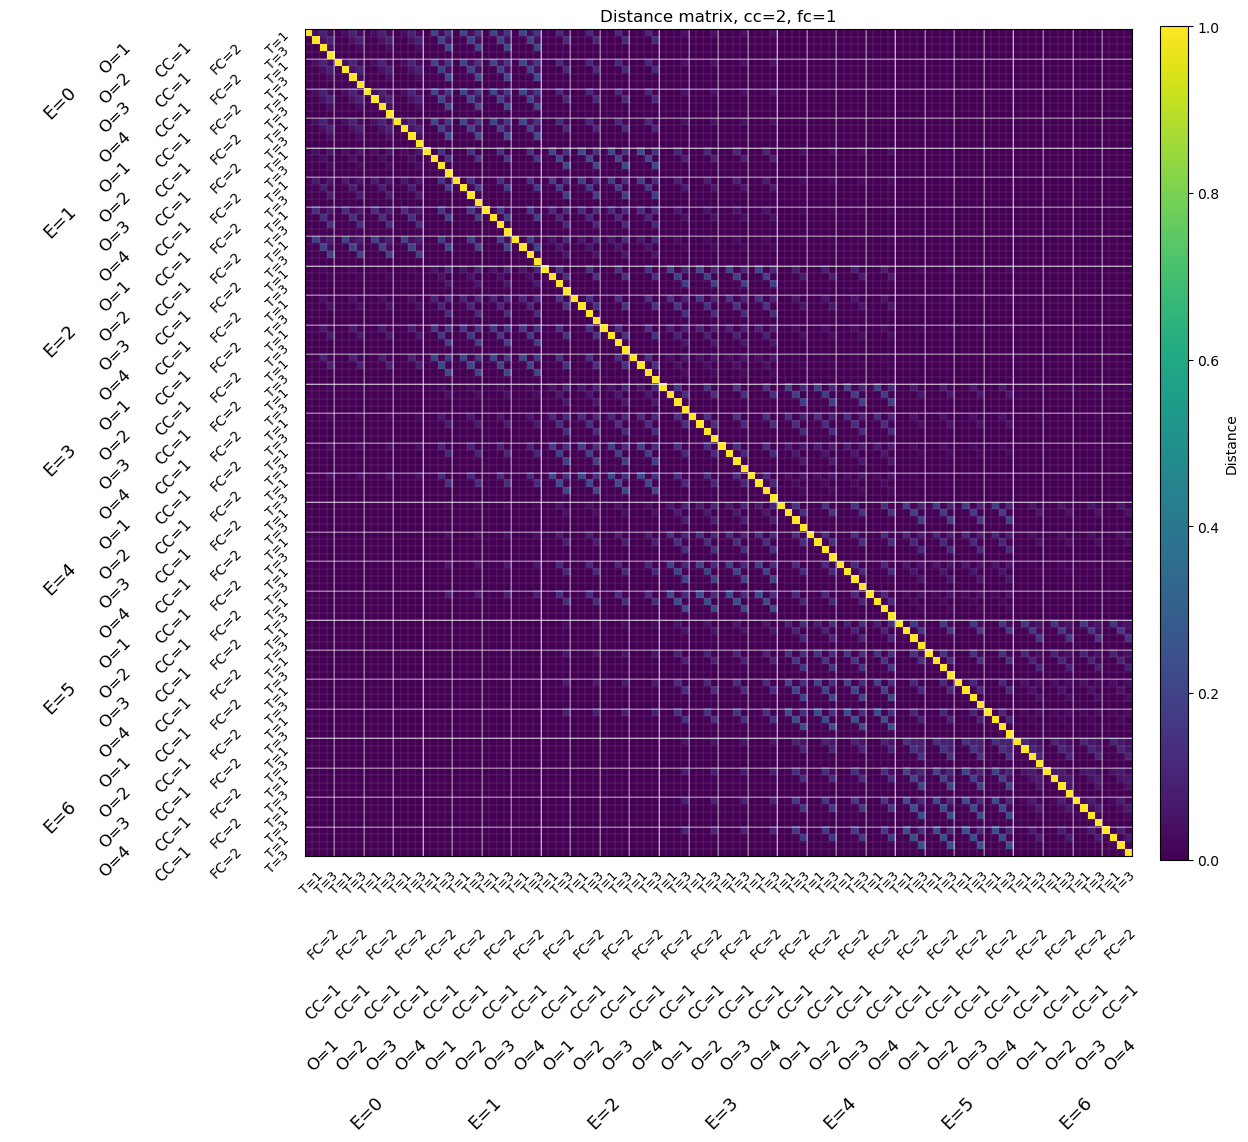

1.0


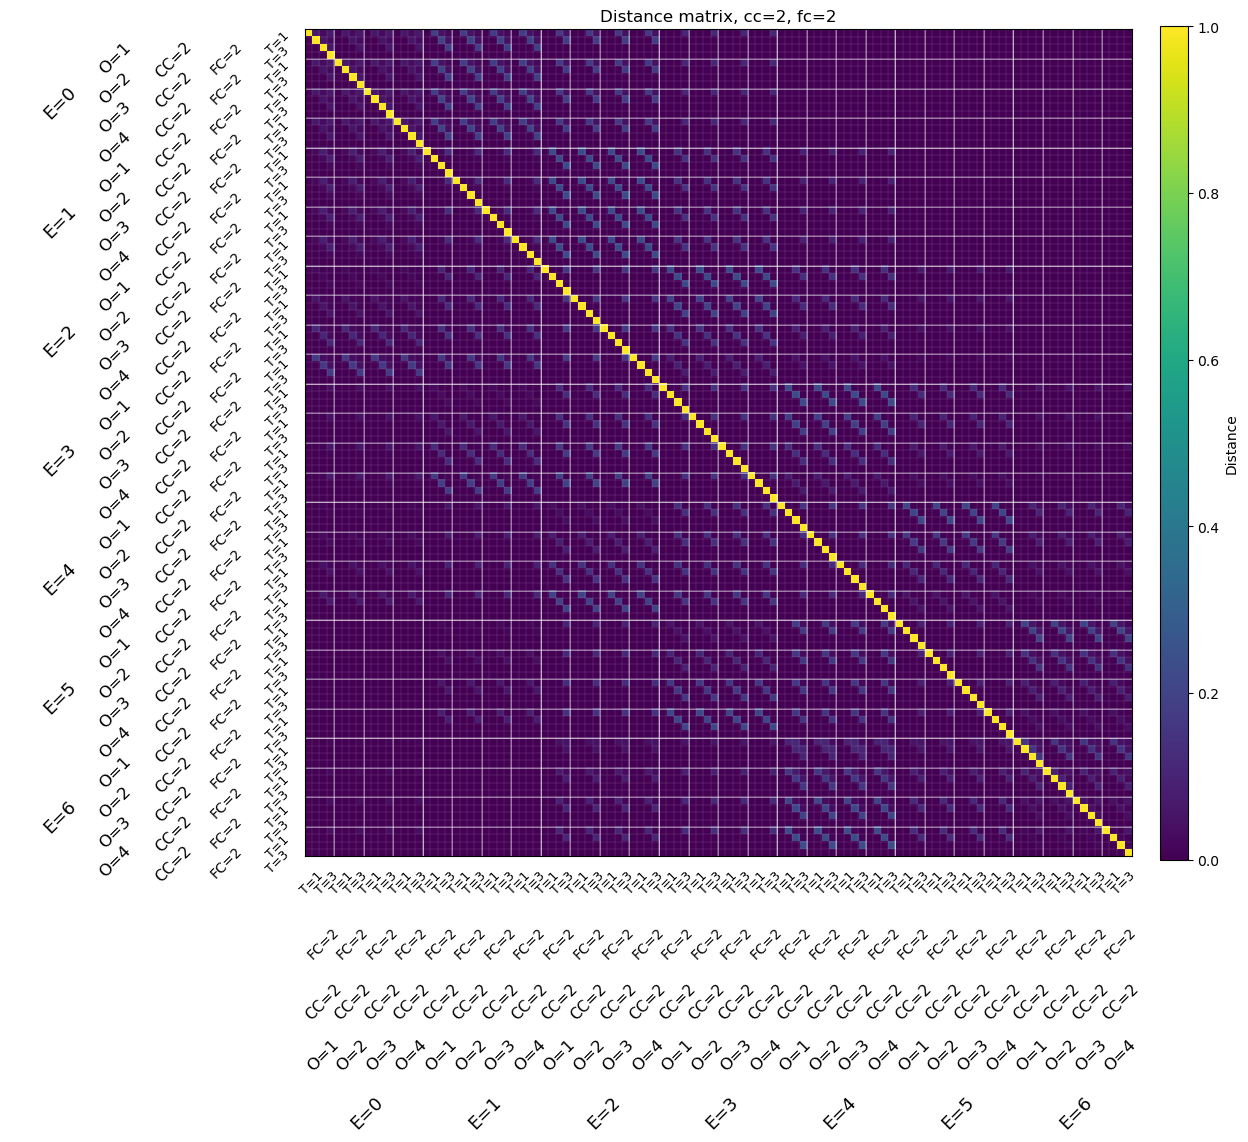

1.0


In [4]:
import numpy as np
import pandas as pd
import os
from scipy.stats import zscore
from stabst.utils import plot_state_matrix, beh_barplot, abstract2ground_value
from scipy.special import expit
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import matplotlib.pyplot as plt

# Specify task parameters:
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()
# Create full MDP and compute optimal policy:
gamma = 0.99
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
# Convert terminal states to absorbing ones:
task_mdp.term_to_abs()
# Compute solution
V_full, Q_full = task_mdp.backward_induction()

# Random policy:
pi_random = np.zeros([len(task.states), task.r.shape[1]]) + 0.5

# Generate successor representation matrix:
t, m = task_mdp.build_sr(task_mdp.soft_policy(Q_full))
print(np.max(m))
print(task_mdp.gamma)
print(np.min(t.sum(axis=1)), np.max(t.sum(axis=1)))
print(np.min(t), np.max(t))
print("is SR close to I:", np.allclose(m, np.eye(m.shape[0])))
print("max |SR-I|:", np.max(np.abs(m - np.eye(m.shape[0]))))
# Plot successor representation matrix:
fig = plot_state_matrix(m , task_mdp.states, feature_names=["E", "O", "CC", "FC", "T"], depth=2, title=f"Occupancy matrix")
plt.show()
# Plot the distance matrix:
for ctrans in [[1, 1], [1, 2], [2, 1], [2, 2]]:
    # Extract only to t=4, as we don't quite care about anything beyond that:
    distances_matrix_reduced = np.zeros([len(task.O) * len(task.E) * 4 * 2, len(task.O) * len(task.E) * 4 * 2])
    states_reduced = []
    ctr1 = 0
    for i, state1 in enumerate(task_mdp.states):
        if state1[-1] > 4:
            continue
        if state1[-2] == ctrans[0] and state1[-3] == ctrans[1]:
            states_reduced.append(state1)
            ctr2 = 0
            for state2 in task_mdp.states:
                if state2[-1] > 4:
                    continue
                if state2[-2] == ctrans[0] and state2[-3] == ctrans[1]:
                    distances_matrix_reduced[ctr1, ctr2] = m[task_mdp.s2i[state1], task_mdp.s2i[state2]]
                    ctr2 += 1
            ctr1 += 1
    fig = plot_state_matrix(distances_matrix_reduced, states_reduced, feature_names=["E", "O", "CC", "FC", "T"], depth=5, title=f"Distance matrix, cc={ctrans[0]}, fc={ctrans[1]}")
    plt.show()
    print(np.max(distances_matrix_reduced))

In [ ]:
eigvals = np.linalg.eigvals(m)
np.set_printoptions(precision=18, suppress=False)
print(eigvals[:20])
print("max |eigval-1| =", np.max(np.abs(eigvals - 1)))
tp_eigs = np.linalg.eigvals(t)
print(tp_eigs[:20])
print("max abs eig of t_pi:", np.max(np.abs(tp_eigs)))

In [6]:
np.sum(m, axis=0)

array([  1.                ,   1.5632990481585203,   2.2089019983913945,
       ...,   2.032495144746335 ,   1.5215685490984503,
       131.99828597252773  ], shape=(1456,))